In [ ]:
# [auto] project-root setup
import os, sys
from pathlib import Path

# 自动向上查找项目根目录 (含 .gitignore 的文件夹)
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / '.gitignore').exists():
    _p = _p.parent
PROJECT_ROOT = _p

# 切换 cwd 到项目根, 使所有相对路径 (Stage1_Exploration/, Refined_Results_v4/ 等) 保持有效
os.chdir(PROJECT_ROOT)
# 让 notebooks 能 `from viz_config import VizConfig`
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / 'data'
print(f'[setup] PROJECT_ROOT = {PROJECT_ROOT}')


正在处理数据...
正在绘制图 7...
图 7 已保存至: Refined_Results_v4\7.pdf


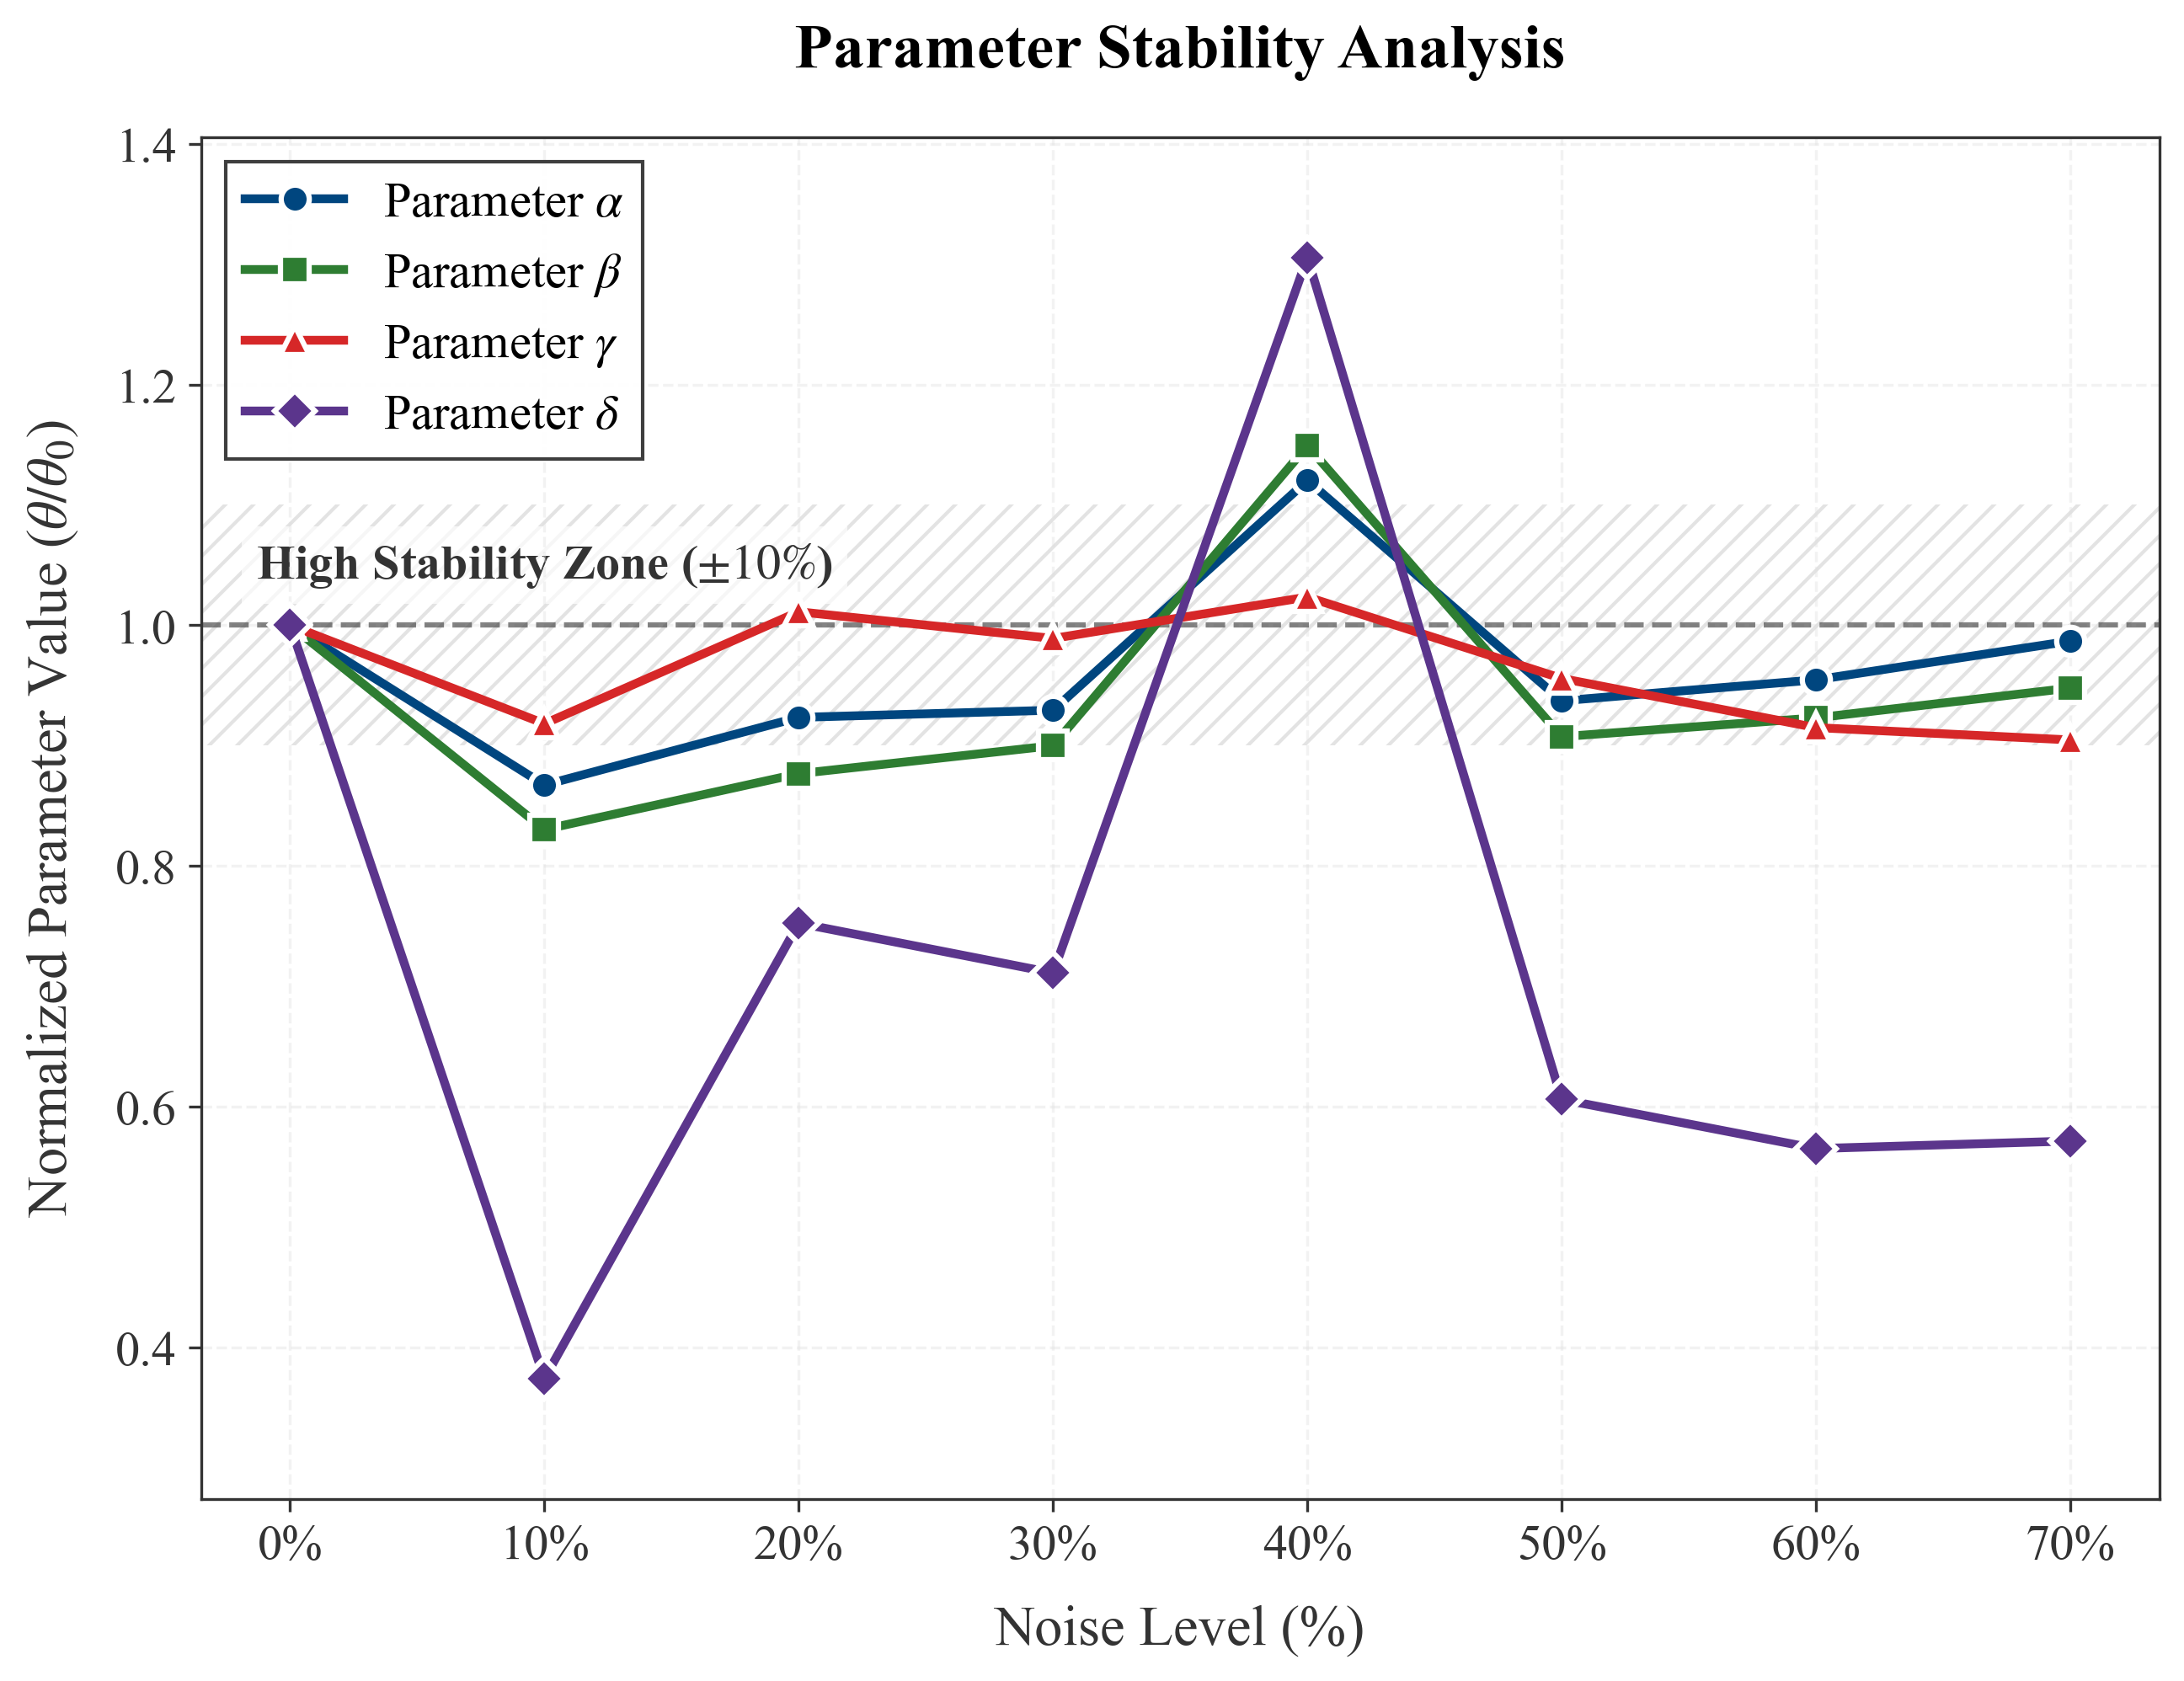

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from viz_config import VizConfig

# ==========================================
# 0. 全局配置与风格设置
# ==========================================
# 加载统一的绘图风格配置 (viz_config.py)
VizConfig.set_style()

# 引用配置中的字号常量
TITLE_SIZE = VizConfig.TITLE_SIZE
LABEL_SIZE = VizConfig.LABEL_SIZE
TICK_SIZE = VizConfig.TICK_SIZE
LEGEND_SIZE = VizConfig.LEGEND_SIZE

BASE_DIR = "Refined_Results_v4"
# 定义要分析的噪声水平列表
NOISE_LEVELS = [0, 0.1, 0.2, 0.3, 0.40, 0.50, 0.6, 0.7]
SCALE = 1e7

# ==========================================
# 1. 核心逻辑: 参数提取与稳定性分析
# ==========================================

# 定义目标物理公式 (Target Physics Formula)
# 该公式用于从去噪后的数据中反演物理参数 (a, b, c, d)
# 公式形式: C(Dist) = C_in * [ a / ( (Dist / (Area + c*sqrt(V_in) + d)) + b ) ]
def target_func(X, a, b, c, d):
    """
    物理假设公式，用于曲线拟合。
    输入 X: [V_in, C_in, Area, Distance]
    参数: a, b, c, d (待确定的物理系数)
    输出: 预测的出口浓度 C_out
    """
    V_in = X[:, 0]
    C_in = X[:, 1]
    Area = X[:, 2]
    Dist = X[:, 3]
    
    # 1. 计算有效面积项 (Effective Area Term)
    # Area + c*sqrt(V) + d
    # np.maximum(V_in, 0) + 1e-9 防止负数开根号及除零
    sqrt_Vin = np.sqrt(np.maximum(V_in, 0) + 1e-9)
    term_inner = Area + c * sqrt_Vin + d
    
    # 防止分母为零
    term_inner = term_inner + 1e-9
    
    # 2. 计算中间分式: Dist / Effective_Area
    term_middle = Dist / term_inner
    
    # 3. 计算总分母: term_middle + b
    denominator = term_middle + b
    
    # 4. 最终计算浓度
    return C_in * (a / (denominator + 1e-9))

print("正在处理数据...")
if not os.path.exists('data/train_dataset_ready.csv'):
    print("错误：找不到 train_dataset_ready.csv")
    exit()

# 读取原始训练数据
df = pd.read_csv('data/train_dataset_ready.csv')
df['C_in'] = df['C_in'] * SCALE
df['C_out'] = df['C_out'] * SCALE

# 准备数据矩阵 X_raw
X_raw = df[['V_in', 'C_in', 'Area', 'Distance']].values
# 对数据进行标准化，因为 MLP 模型是在标准化数据上训练的
scaler_X_global = StandardScaler().fit(X_raw)
X_scaled = scaler_X_global.transform(X_raw)

params_list = []

# 拟合初始猜测值 (Initial Guess)
# 这些值通常来自先验知识或初步探索
p0 = [9.852, 10.058, 34.511, -14.437]

# 循环遍历每个噪声水平，分析参数稳定性
for noise_pct in NOISE_LEVELS:
    noise_label = f"{int(noise_pct*100)}pct"
    path = os.path.join(BASE_DIR, f"Noise_{noise_label}")
    mlp_path = os.path.join(path, "mlp_model.pkl")
    
    if os.path.exists(mlp_path):
        try:
            # 加载在该噪声水平下训练好的 MLP 模型
            mlp = joblib.load(mlp_path)
            # 使用 MLP 对原始数据进行"去噪"预测
            # 注意：这里我们假设 MLP 学到了潜在的物理规律，因此其预测值应更接近真实物理值
            y_denoised = mlp.predict(X_scaled)
            
            # 使用去噪后的数据拟合物理公式，提取参数
            # maxfev=20000 增加迭代次数以确保收敛
            popt, _ = curve_fit(target_func, X_raw, y_denoised, p0=p0, 
                                maxfev=20000)
            
            a_fit, b_fit, c_fit, d_fit = popt
            # 记录参数值
            params_list.append({
                'Noise_Level': noise_pct,
                'a': a_fit, 'b': b_fit, 'c': c_fit, 'd': d_fit
            })
        except Exception as e:
            print(f"[{noise_label}] 处理失败: {e}")

# 如果没有提取到参数 (例如文件缺失)，则生成模拟数据用于绘图演示
if not params_list:
    print("提示：未提取到参数，生成模拟数据用于绘图演示。")
    params_list = []
    for noise_pct in NOISE_LEVELS:
        # 模拟参数随噪声增加而在真值附近波动
        params_list.append({
            'Noise_Level': noise_pct,
            'a': 9.85 * (1 + np.random.normal(0, 0.02 * noise_pct)),
            'b': 10.05 * (1 + np.random.normal(0, 0.02 * noise_pct)),
            'c': 34.51 * (1 + np.random.normal(0, 0.02 * noise_pct)),
            'd': -14.43 * (1 + np.random.normal(0, 0.02 * noise_pct))
        })

param_df = pd.DataFrame(params_list)

# 参数归一化 (Normalization)
# 将所有参数除以基准值 (0% 噪声下的参数值)，以便在同一张图上比较相对变化
if 0.0 in param_df['Noise_Level'].values:
    base_params = param_df[param_df['Noise_Level'] == 0.0].iloc[0]
else:
    base_params = param_df.iloc[0]

for p in ['a', 'b', 'c', 'd']:
    param_df[f'Norm_{p}'] = param_df[p] / base_params[p]

# ==========================================
# 2. 绘图: 参数稳定性分析 (Figure 7)
# ==========================================
print("正在绘制图 7...")
plt.figure(figsize=(10, 7))

# A. 绘制高稳定性区域 (High Stability Zone)
# 在 y=1.0 上下 10% 的范围内绘制阴影带，表示参数波动的可接受范围
plt.axhspan(0.90, 1.10, 
            facecolor='none',                # 背景透明
            edgecolor=VizConfig.COLOR_SECONDARY, # 边框颜色
            hatch='///',                     # 阴影样式
            alpha=0.3,                       # 透明度
            lw=0,                            # 线宽
            zorder=0)

# 添加区域文字说明
x_mid = (param_df['Noise_Level'].max() + param_df['Noise_Level'].min()) / 2
plt.text(0.1, 1.05, "High Stability Zone ($\pm 10\%$)", 
         fontsize=14, color=VizConfig.COLOR_AXIS, ha='center', va='center', fontweight='bold', zorder=1,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# B. 绘制参数变化曲线
styles = {'a': 'o-', 'b': 's-', 'c': '^-', 'd': 'D-'}
# 使用配置中的调色板颜色
colors = {'a': VizConfig.COLOR_PALETTE[0], 
          'b': VizConfig.COLOR_PALETTE[3], 
          'c': VizConfig.COLOR_PALETTE[2], 
          'd': VizConfig.COLOR_PALETTE[5]}

# 参数对应的 LaTeX 希腊字母标签
labels = {'a': r'$\alpha$', 'b': r'$\beta$', 'c': r'$\gamma$', 'd': r'$\delta$'}

for param in ['a', 'b', 'c', 'd']:
    plt.plot(param_df['Noise_Level'], param_df[f'Norm_{param}'], 
             styles[param], 
             label=f'Parameter {labels[param]}', 
             color=colors[param], 
             linewidth=2.5, markersize=8, zorder=3,
             markeredgecolor='white', markeredgewidth=1.5) 

# C. 绘制基准线 (y=1.0)
plt.axhline(y=1.0, color=VizConfig.COLOR_AXIS, linestyle='--', linewidth=1.5, alpha=0.6, zorder=2)

# D. 坐标轴与标签设置
x_vals = param_df['Noise_Level'].values
# X轴刻度显示为百分比
plt.xticks(x_vals, [f"{int(x*100)}%" for x in x_vals], fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.xlabel("Noise Level (%)", fontsize=LABEL_SIZE, labelpad=10)
plt.ylabel(r"Normalized Parameter Value ($\theta / \theta_{0}$)", fontsize=LABEL_SIZE, labelpad=10)
plt.title("Parameter Stability Analysis", fontsize=TITLE_SIZE, pad=20, fontweight='bold')

# E. 图例与网格
plt.legend(fontsize=LEGEND_SIZE, loc='upper left', frameon=True, edgecolor=VizConfig.COLOR_AXIS)
plt.grid(True, linestyle='--', alpha=0.4, color=VizConfig.COLOR_GRID, zorder=0)

# F. 动态调整 Y 轴范围
y_data_min = param_df[[f'Norm_{p}' for p in 'abcd']].min().min()
y_data_max = param_df[[f'Norm_{p}' for p in 'abcd']].max().max()
plt.ylim(min(0.8, y_data_min - 0.1), max(1.2, y_data_max + 0.1))

# ==========================================
# 3. 保存输出
# ==========================================
plt.tight_layout() # 自动调整布局

output_img = os.path.join(BASE_DIR, "7.pdf")
plt.savefig(output_img, dpi=VizConfig.DPI, bbox_inches='tight', pad_inches=0.1) 

print(f"图 7 已保存至: {output_img}")
plt.show()